<a href="https://colab.research.google.com/github/nguyenxuandinhit/TH_Deep_Learning/blob/main/Deep_Tuan3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

!pip install flask flask-ngrok pyngrok -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)

TensorFlow version: 2.20.0
Keras version: 3.13.2


In [3]:
# ==================== BÀI TẬP 1: CIFAR-10 ====================

# 1.1 Đọc dữ liệu CIFAR-10
(X_train_c10, y_train_c10), (X_test_c10, y_test_c10) = tf.keras.datasets.cifar10.load_data()

label_names_cifar10 = ['airplane','automobile','bird','cat','deer',
                       'dog','frog','horse','ship','truck']

print('X_train shape:', X_train_c10.shape)   # (50000, 32, 32, 3)
print('X_test shape :', X_test_c10.shape)    # (10000, 32, 32, 3)
print('y_train shape:', y_train_c10.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
X_train shape: (50000, 32, 32, 3)
X_test shape : (10000, 32, 32, 3)
y_train shape: (50000, 1)


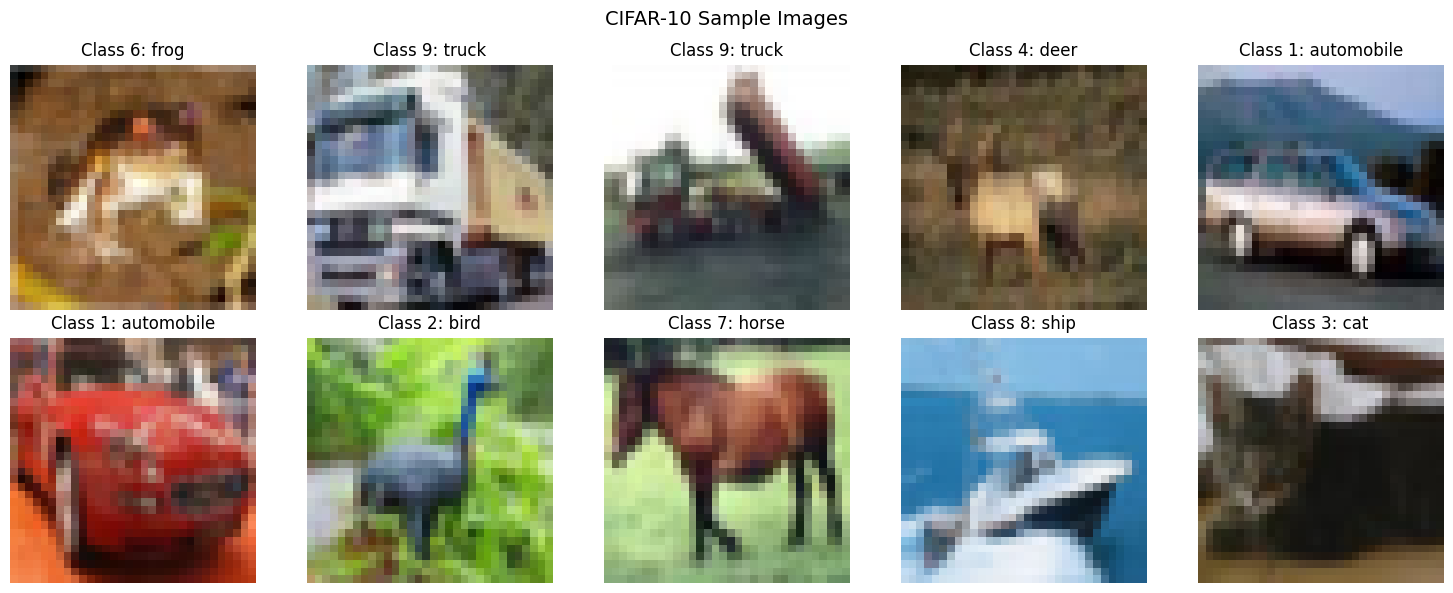

In [4]:
# 1.2 Trực quan hóa dữ liệu
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_train_c10[i])
    axes[i].set_title(f'Class {y_train_c10[i][0]}: {label_names_cifar10[y_train_c10[i][0]]}')
    axes[i].axis('off')
plt.suptitle('CIFAR-10 Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# 1.3 Tiền xử lý dữ liệu
# Reshape: 32x32x3 → 3072 (flatten)
X_train_c10_flat = X_train_c10.reshape(50000, 32*32*3).astype('float32') / 255.0
X_test_c10_flat  = X_test_c10.reshape(10000, 32*32*3).astype('float32') / 255.0

# Flatten label (50000,1) → (50000,)
y_train_c10 = y_train_c10.flatten()
y_test_c10  = y_test_c10.flatten()

print('X_train_flat shape:', X_train_c10_flat.shape)
print('Number of classes  :', len(np.unique(y_train_c10)))

X_train_flat shape: (50000, 3072)
Number of classes  : 10


In [6]:
# 1.4 Xây dựng mô hình ANN cho CIFAR-10
cifar10_model = Sequential([
    Dense(512, input_dim=X_train_c10_flat.shape[1],
          kernel_initializer='uniform', activation='relu'),
    Dropout(0.3),
    Dense(256, kernel_initializer='uniform', activation='relu'),
    Dropout(0.3),
    Dense(128, kernel_initializer='uniform', activation='relu'),
    Dense(10,  kernel_initializer='uniform', activation='softmax')
])

cifar10_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
cifar10_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# 1.5 Huấn luyện mô hình CIFAR-10
cifar10_fit = cifar10_model.fit(
    X_train_c10_flat, y_train_c10,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    verbose=1
)

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.2723 - loss: 1.9690 - val_accuracy: 0.3370 - val_loss: 1.8205
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.3408 - loss: 1.8259 - val_accuracy: 0.3560 - val_loss: 1.7687
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 15s 43ms/step - accuracy: 0.3617 - loss: 1.7731 - val_accuracy: 0.3836 - val_loss: 1.7327
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.3768 - loss: 1.7351 - val_accuracy: 0.3864 - val_loss: 1.6947
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.3885 - loss: 1.7043 - val_accuracy: 0.4062 - val_loss: 1.6464
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.3959 - loss: 1.6758 - val_accuracy: 0.4198 - val_loss: 1.6291
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.4044 - loss: 1.6530 - val_accuracy: 0.4386 - val_loss: 1.5875
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.4136 - loss: 1.6296 - 

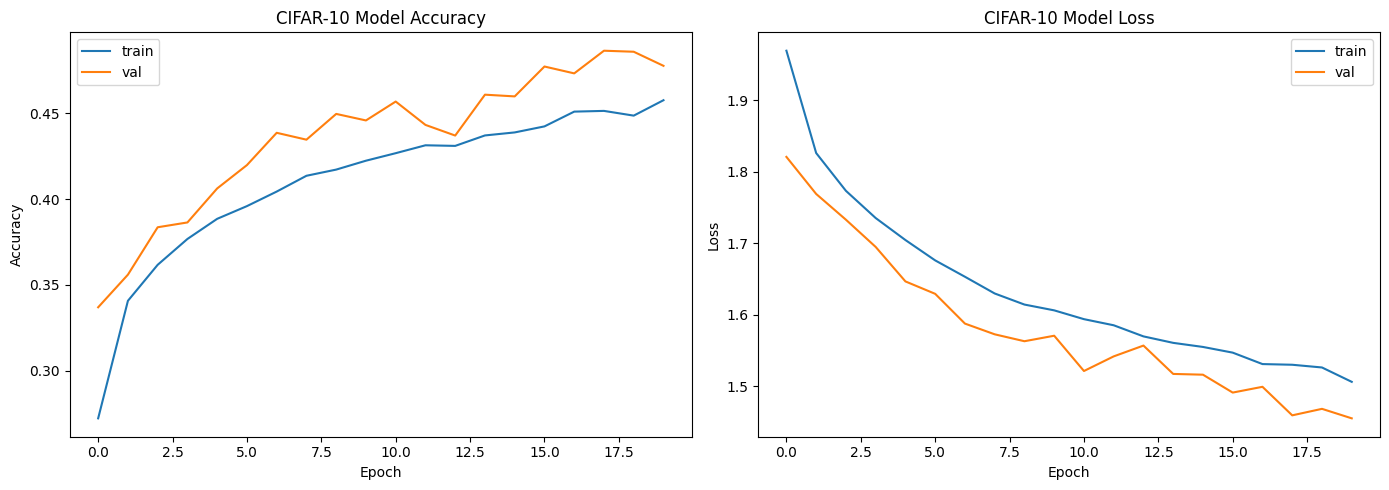


Test Accuracy: 0.4766 | Test Loss: 1.4524


In [8]:
# 1.6 Đánh giá mô hình CIFAR-10
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(cifar10_fit.history['accuracy'], label='train')
ax1.plot(cifar10_fit.history['val_accuracy'], label='val')
ax1.set_title('CIFAR-10 Model Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend()

ax2.plot(cifar10_fit.history['loss'], label='train')
ax2.plot(cifar10_fit.history['val_loss'], label='val')
ax2.set_title('CIFAR-10 Model Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

test_loss, test_acc = cifar10_model.evaluate(X_test_c10_flat, y_test_c10, verbose=0)
print(f'\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


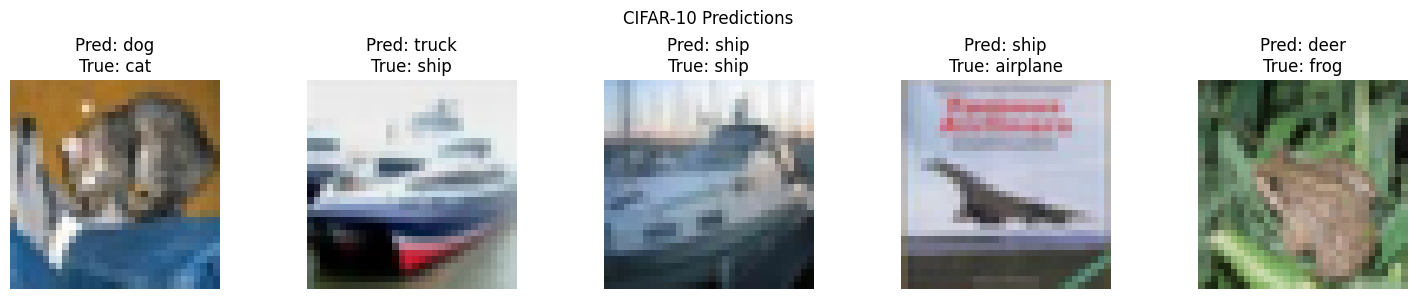

In [9]:
# 1.7 Dự báo ảnh mới (CIFAR-10)
preds_c10 = np.argmax(cifar10_model.predict(X_test_c10_flat[:5]), axis=1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_test_c10[i])
    ax.set_title(f'Pred: {label_names_cifar10[preds_c10[i]]}\nTrue: {label_names_cifar10[y_test_c10[i]]}')
    ax.axis('off')
plt.suptitle('CIFAR-10 Predictions', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
# ==================== BÀI TẬP 2: MNIST ====================

# 2.1 Đọc dữ liệu MNIST
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = tf.keras.datasets.mnist.load_data()

print('X_train shape:', X_train_mnist.shape)   # (60000, 28, 28)
print('X_test shape :', X_test_mnist.shape)
print('Classes      :', np.unique(y_train_mnist))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28)
X_test shape : (10000, 28, 28)
Classes      : [0 1 2 3 4 5 6 7 8 9]


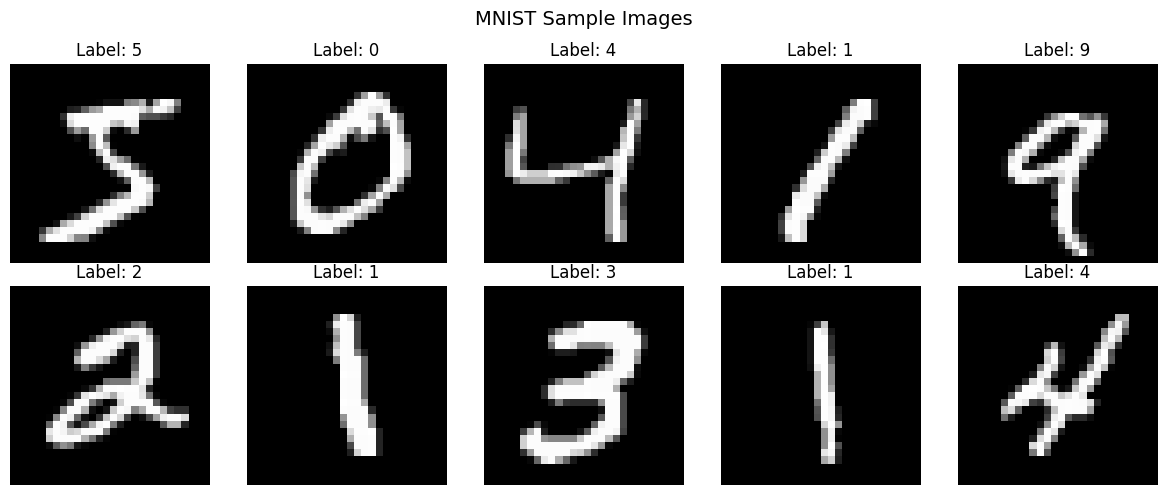

In [11]:
# 2.2 Trực quan hóa
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_train_mnist[i], cmap='gray')
    axes[i].set_title(f'Label: {y_train_mnist[i]}')
    axes[i].axis('off')
plt.suptitle('MNIST Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# 2.3 Tiền xử lý
X_train_mnist_flat = X_train_mnist.reshape(60000, 784).astype('float32') / 255.0
X_test_mnist_flat  = X_test_mnist.reshape(10000, 784).astype('float32') / 255.0

print('X_train_flat shape:', X_train_mnist_flat.shape)

X_train_flat shape: (60000, 784)


In [13]:
# 2.4 Xây dựng mô hình ANN cho MNIST
mnist_model = Sequential([
    Dense(256, input_dim=784, kernel_initializer='uniform', activation='relu'),
    Dropout(0.2),
    Dense(128, kernel_initializer='uniform', activation='relu'),
    Dense(10,  kernel_initializer='uniform', activation='softmax')
])

mnist_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
mnist_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# 2.5 Huấn luyện MNIST model
mnist_fit = mnist_model.fit(
    X_train_mnist_flat, y_train_mnist,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    verbose=1
)

Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8859 - loss: 0.4078 - val_accuracy: 0.9542 - val_loss: 0.1543
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9528 - loss: 0.1590 - val_accuracy: 0.9708 - val_loss: 0.0983
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9658 - loss: 0.1126 - val_accuracy: 0.9765 - val_loss: 0.0786
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9735 - loss: 0.0867 - val_accuracy: 0.9788 - val_loss: 0.0728
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9785 - loss: 0.0699 - val_accuracy: 0.9788 - val_loss: 0.0701
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9811 - loss: 0.0581 - val_accuracy: 0.9773 - val_loss: 0.0705
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9840 - loss: 0.0499 - val_accuracy: 0.9803 - val_loss: 0.0647
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9855 - loss: 0.0429 - val_accuracy

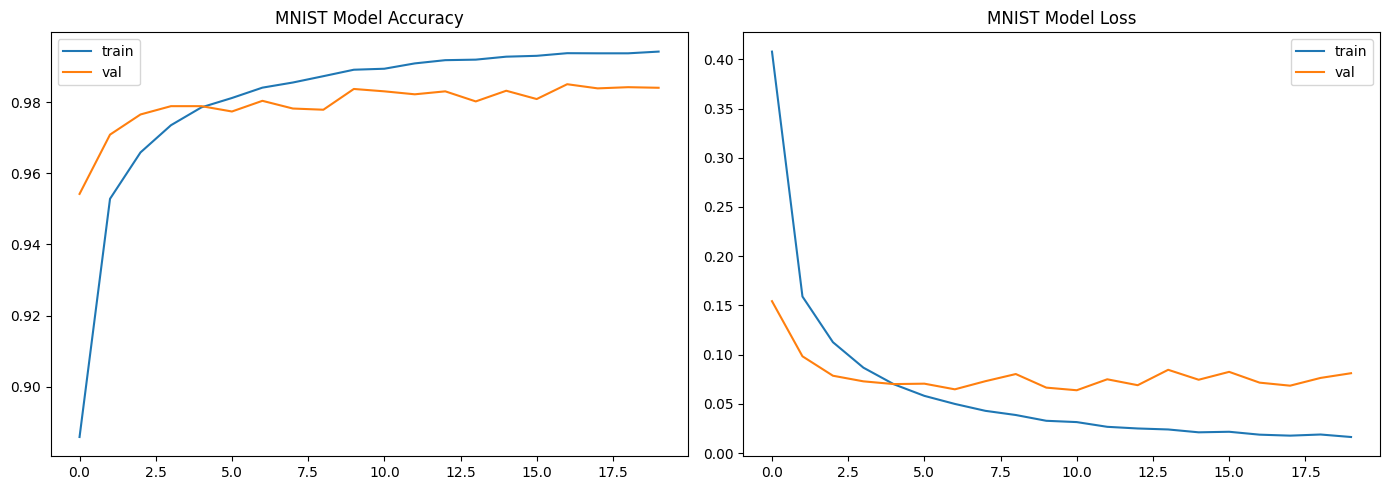

Test Accuracy: 0.9800 | Test Loss: 0.0758


In [16]:
# 2.6 Đánh giá MNIST model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(mnist_fit.history['accuracy'], label='train')
ax1.plot(mnist_fit.history['val_accuracy'], label='val')
ax1.set_title('MNIST Model Accuracy'); ax1.legend()

ax2.plot(mnist_fit.history['loss'], label='train')
ax2.plot(mnist_fit.history['val_loss'], label='val')
ax2.set_title('MNIST Model Loss'); ax2.legend()
plt.tight_layout(); plt.show()

test_loss, test_acc = mnist_model.evaluate(X_test_mnist_flat, y_test_mnist, verbose=0)
print(f'Test Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted: [7 2 1 0 4 1 4 9 5 9]
True     : [7 2 1 0 4 1 4 9 5 9]


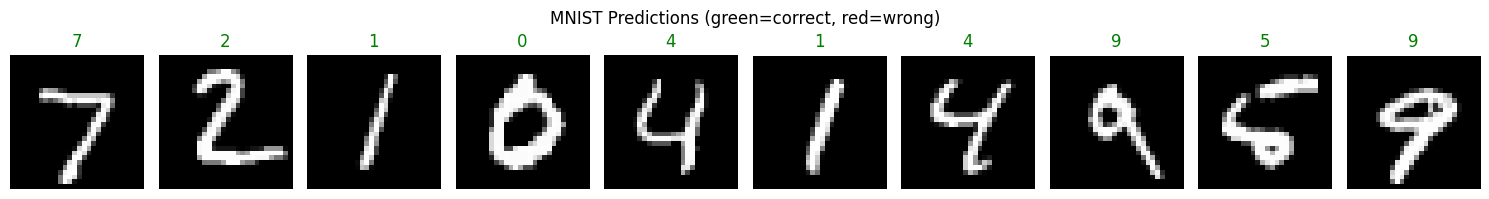

In [17]:
# 2.7 Dự báo (MNIST)
preds_mnist = np.argmax(mnist_model.predict(X_test_mnist_flat[:10]), axis=1)
print('Predicted:', preds_mnist)
print('True     :', y_test_mnist[:10])

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(X_test_mnist[i], cmap='gray')
    color = 'green' if preds_mnist[i] == y_test_mnist[i] else 'red'
    ax.set_title(str(preds_mnist[i]), color=color)
    ax.axis('off')
plt.suptitle('MNIST Predictions (green=correct, red=wrong)')
plt.tight_layout(); plt.show()

In [19]:
# ==================== BÀI TẬP 3: CAT vs DOG ====================
# Nếu chưa có dataset, tải từ Kaggle (cần API key) hoặc dùng TF datasets
# Ở đây dùng tensorflow_datasets để demo không cần file thủ công

import tensorflow_datasets as tfds

# Tải cats_vs_dogs dataset
(ds_train, ds_test), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True
)

IMG_SIZE = (64, 64)
BATCH_SIZE = 64

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

ds_train = ds_train.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_test  = ds_test.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print('Dataset loaded. Labels: 0=Cat, 1=Dog')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.JR8U5H_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
Dataset loaded. Labels: 0=Cat, 1=Dog


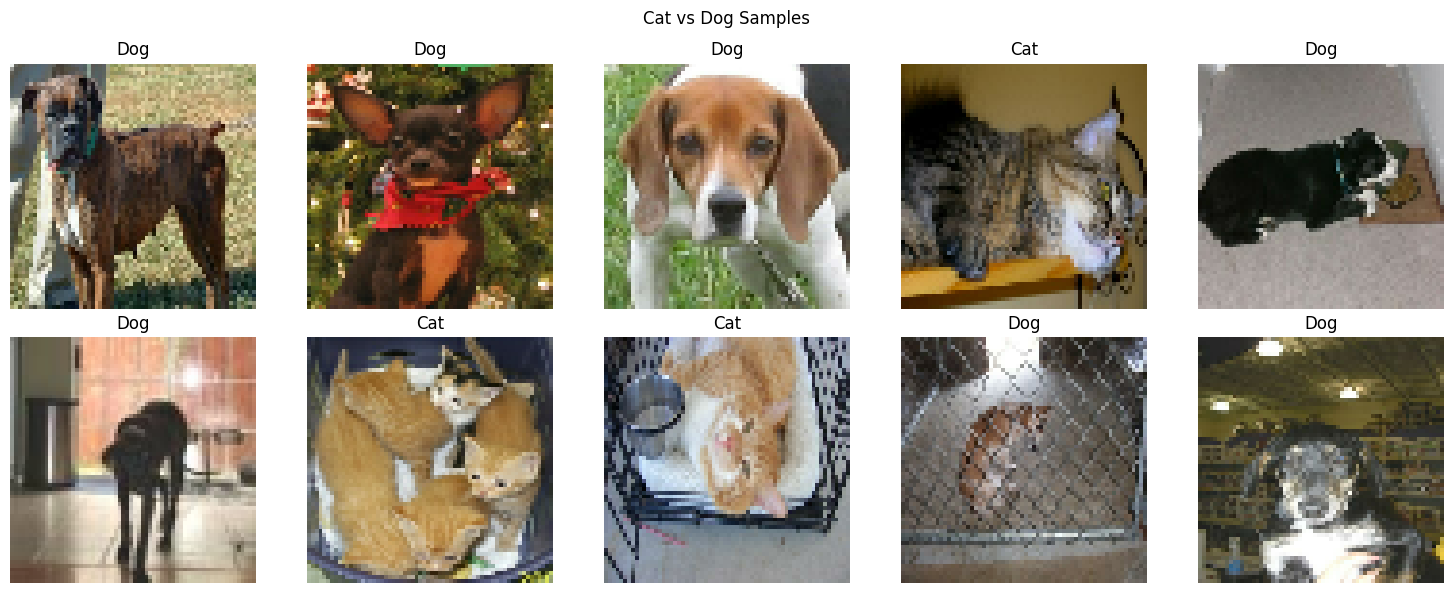

In [20]:
# 3.2 Trực quan hóa Cat vs Dog
label_names_catdog = ['Cat', 'Dog']

sample_batch = next(iter(ds_train))
images_sample, labels_sample = sample_batch

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(images_sample[i].numpy())
    axes[i].set_title(label_names_catdog[labels_sample[i].numpy()])
    axes[i].axis('off')
plt.suptitle('Cat vs Dog Samples')
plt.tight_layout()
plt.show()

In [21]:
# 3.3 Xây dựng ANN Cat vs Dog
catdog_model = Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(512, activation='relu', kernel_initializer='uniform'),
    Dropout(0.4),
    Dense(256, activation='relu', kernel_initializer='uniform'),
    Dropout(0.3),
    Dense(128, activation='relu', kernel_initializer='uniform'),
    Dense(1, activation='sigmoid')   # binary: 0=cat, 1=dog
])

catdog_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
catdog_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,456,321 (24.63 MB)

 Trainable params: 6,456,321 (24.63 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# 3.4 Huấn luyện Cat vs Dog
catdog_fit = catdog_model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=15,
    verbose=1
)

Epoch 1/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 56s 185ms/step - accuracy: 0.5141 - loss: 0.7123 - val_accuracy: 0.5653 - val_loss: 0.6856
Epoch 2/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 81s 182ms/step - accuracy: 0.5390 - loss: 0.6862 - val_accuracy: 0.4895 - val_loss: 0.6878
Epoch 3/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 54s 183ms/step - accuracy: 0.5417 - loss: 0.6848 - val_accuracy: 0.6079 - val_loss: 0.6674
Epoch 4/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 54s 184ms/step - accuracy: 0.5488 - loss: 0.6853 - val_accuracy: 0.5778 - val_loss: 0.6809
Epoch 5/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 54s 185ms/step - accuracy: 0.5358 - loss: 0.6863 - val_accuracy: 0.5823 - val_loss: 0.6759
Epoch 6/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 82s 186ms/step - accuracy: 0.5507 - loss: 0.6814 - val_accuracy: 0.5774 - val_loss: 0.6766
Epoch 7/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 81s 184ms/step - accuracy: 0.5634 - loss: 0.6791 - val_accuracy: 0.5905 - val_loss: 0.6739
Epoch 8/15
291/291 ━━━━━━━━━━━━━━━━━━━━ 87s 202ms/step - accuracy: 0.5724 - loss: 0

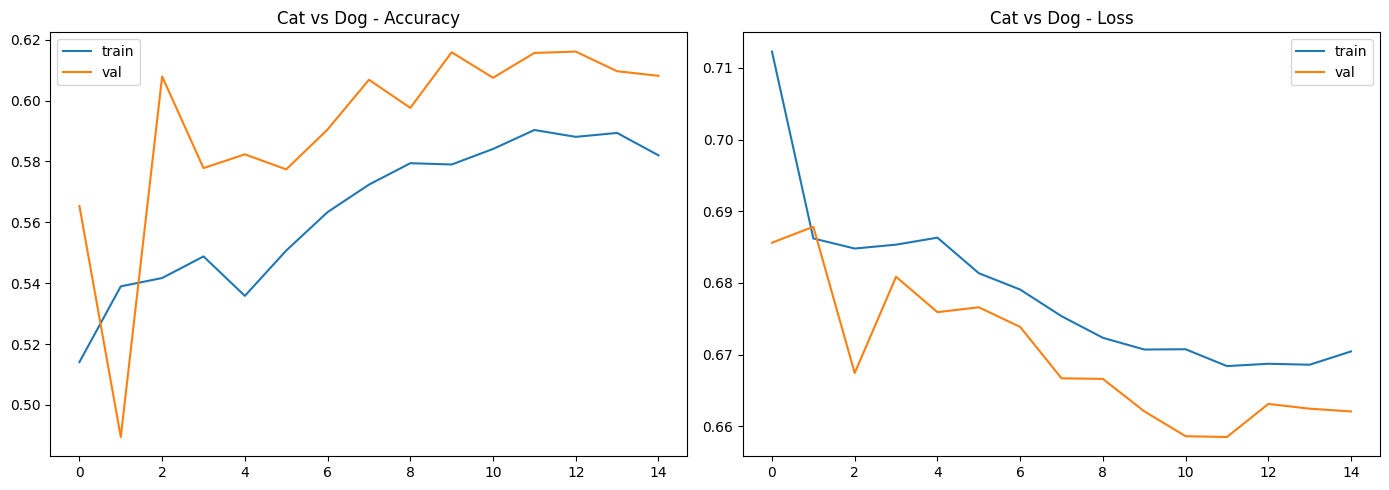

Test Accuracy: 0.6081


In [23]:
# 3.5 Đánh giá Cat vs Dog
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(catdog_fit.history['accuracy'], label='train')
ax1.plot(catdog_fit.history['val_accuracy'], label='val')
ax1.set_title('Cat vs Dog - Accuracy'); ax1.legend()

ax2.plot(catdog_fit.history['loss'], label='train')
ax2.plot(catdog_fit.history['val_loss'], label='val')
ax2.set_title('Cat vs Dog - Loss'); ax2.legend()
plt.tight_layout(); plt.show()

test_loss, test_acc = catdog_model.evaluate(ds_test, verbose=0)
print(f'Test Accuracy: {test_acc:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


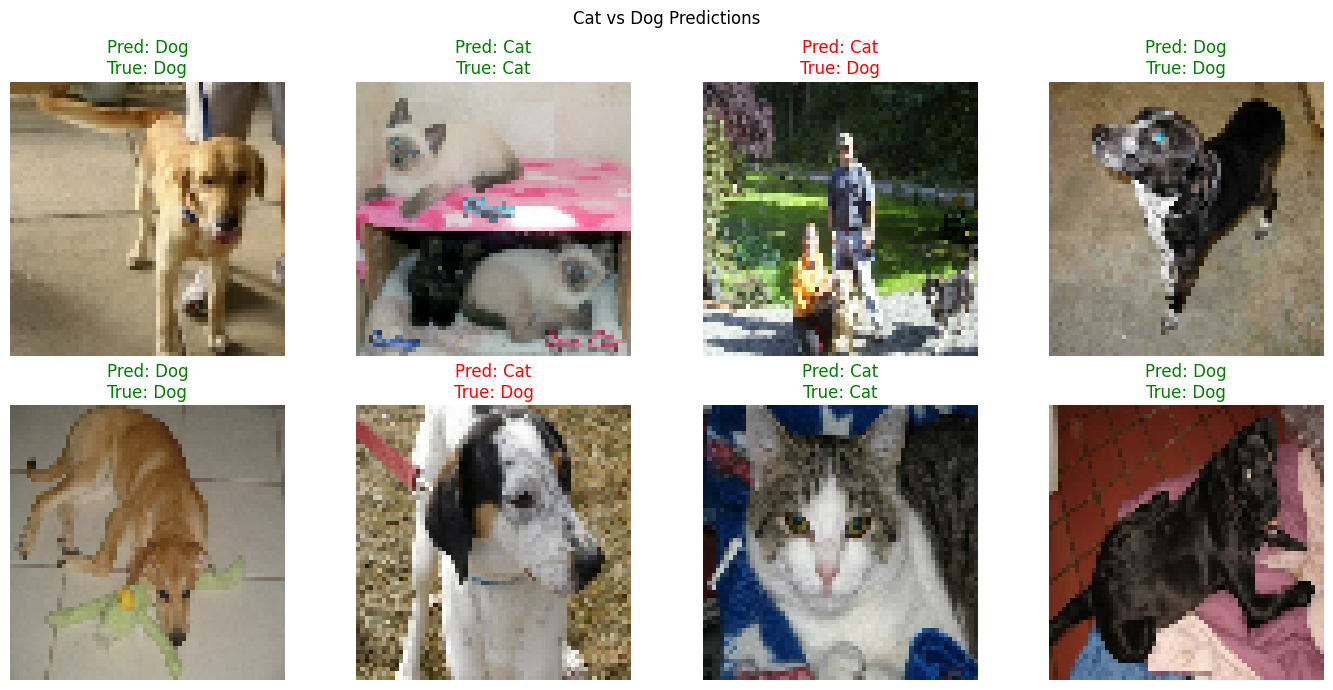

In [24]:
# 3.6 Dự báo Cat vs Dog
test_imgs, test_labels = next(iter(ds_test))
preds_catdog = (catdog_model.predict(test_imgs[:8]) > 0.5).astype(int).flatten()

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()
for i in range(8):
    axes[i].imshow(test_imgs[i].numpy())
    true_label = label_names_catdog[test_labels[i].numpy()]
    pred_label = label_names_catdog[preds_catdog[i]]
    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(f'Pred: {pred_label}\nTrue: {true_label}', color=color)
    axes[i].axis('off')
plt.suptitle('Cat vs Dog Predictions')
plt.tight_layout(); plt.show()

In [25]:
# ==================== BÀI TẬP 4: ADULT INCOME ====================

# 4.1 Đọc dữ liệu Adult từ UCI (hoặc file giảng viên cung cấp)
# Nếu có file local: adult = pd.read_csv('/content/adult.csv')
# Ở đây dùng URL trực tiếp từ UCI

col_names = ['age','workclass','fnlwgt','education','education_num',
             'marital_status','occupation','relationship','race','sex',
             'capital_gain','capital_loss','hours_per_week','native_country','income']

adult = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data',
    names=col_names, sep=', ', engine='python', na_values='?'
)

print('Shape:', adult.shape)
adult.head()

Shape: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Thu nhập phân bố:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


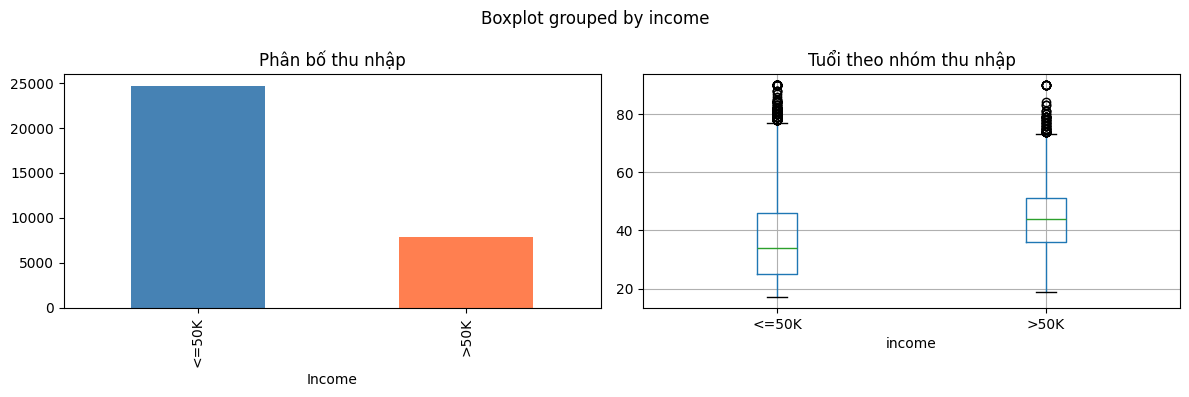

In [26]:
# 4.2 Khám phá dữ liệu
print('Thu nhập phân bố:')
print(adult['income'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
adult['income'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','coral'])
axes[0].set_title('Phân bố thu nhập'); axes[0].set_xlabel('Income')

adult.boxplot(column='age', by='income', ax=axes[1])
axes[1].set_title('Tuổi theo nhóm thu nhập')
plt.tight_layout(); plt.show()

In [27]:
# 4.3 Tiền xử lý dữ liệu
adult_clean = adult.dropna().copy()

# Encode categorical columns
cat_cols = ['workclass','education','marital_status','occupation',
            'relationship','race','sex','native_country']

le = LabelEncoder()
for col in cat_cols:
    adult_clean[col] = le.fit_transform(adult_clean[col])

# Encode nhãn: <=50K → 0, >50K → 1
adult_clean['income'] = (adult_clean['income'] == '>50K').astype(int)

X_adult = adult_clean.drop('income', axis=1).values
y_adult = adult_clean['income'].values

# Feature scaling
scaler_adult = MinMaxScaler()
X_adult = scaler_adult.fit_transform(X_adult)

# Tách train/test
X_train_adult, X_test_adult, y_train_adult, y_test_adult = train_test_split(
    X_adult, y_adult, test_size=0.2, random_state=42
)

print('Train size:', X_train_adult.shape)
print('Test  size:', X_test_adult.shape)
print('Features  :', X_train_adult.shape[1])

Train size: (24129, 14)
Test  size: (6033, 14)
Features  : 14


In [28]:
# 4.4 Xây dựng ANN
adult_model = Sequential([
    Dense(64, input_dim=X_train_adult.shape[1],
          kernel_initializer='uniform', activation='relu'),
    Dropout(0.3),
    Dense(32, kernel_initializer='uniform', activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')   # binary output
])

adult_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
adult_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# 4.5 Huấn luyện
adult_fit = adult_model.fit(
    X_train_adult, y_train_adult,
    validation_split=0.1,
    epochs=30,
    batch_size=256,
    verbose=1
)

Epoch 1/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7383 - loss: 0.5936 - val_accuracy: 0.7522 - val_loss: 0.5343
Epoch 2/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7530 - loss: 0.5030 - val_accuracy: 0.7563 - val_loss: 0.4653
Epoch 3/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7764 - loss: 0.4642 - val_accuracy: 0.7953 - val_loss: 0.4390
Epoch 4/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7933 - loss: 0.4413 - val_accuracy: 0.8114 - val_loss: 0.4140
Epoch 5/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8094 - loss: 0.4182 - val_accuracy: 0.8230 - val_loss: 0.3938
Epoch 6/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8189 - loss: 0.3991 - val_accuracy: 0.8293 - val_loss: 0.3747
Epoch 7/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8246 - loss: 0.3816 - val_accuracy: 0.8280 - val_loss: 0.3598
Epoch 8/30
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8300 - loss: 0.3706 - val_accuracy: 0.8293 - val_loss:

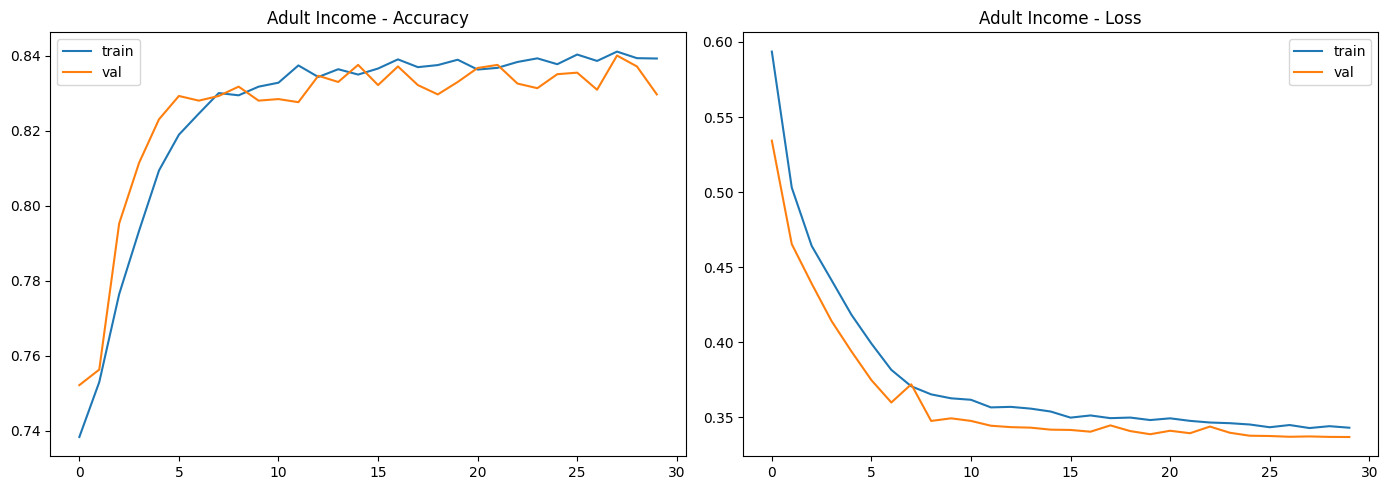

189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test Accuracy: 0.8471738770097795

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.87      0.94      0.90      4503
        >50K       0.77      0.57      0.65      1530

    accuracy                           0.85      6033
   macro avg       0.82      0.76      0.78      6033
weighted avg       0.84      0.85      0.84      6033



In [30]:
# 4.6 Đánh giá Adult Model
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(adult_fit.history['accuracy'], label='train')
ax1.plot(adult_fit.history['val_accuracy'], label='val')
ax1.set_title('Adult Income - Accuracy'); ax1.legend()

ax2.plot(adult_fit.history['loss'], label='train')
ax2.plot(adult_fit.history['val_loss'], label='val')
ax2.set_title('Adult Income - Loss'); ax2.legend()
plt.tight_layout(); plt.show()

y_pred_adult = (adult_model.predict(X_test_adult) > 0.5).astype(int).flatten()
print('Test Accuracy:', accuracy_score(y_test_adult, y_pred_adult))
print('\nClassification Report:')
print(classification_report(y_test_adult, y_pred_adult,
                            target_names=['<=50K', '>50K']))

In [31]:
# 4.7 Dự báo người mới
# Ví dụ: 1 mẫu từ tập test
sample_idx = 0
sample_input = X_test_adult[sample_idx].reshape(1, -1)
prob = adult_model.predict(sample_input)[0][0]
pred_class = '>50K' if prob > 0.5 else '<=50K'
true_class = '>50K' if y_test_adult[sample_idx] == 1 else '<=50K'
print(f'Xác suất >50K: {prob:.4f}')
print(f'Dự báo: {pred_class} | Thực tế: {true_class}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Xác suất >50K: 0.1694
Dự báo: <=50K | Thực tế: >50K


In [32]:
# ==================== BÀI TẬP 5: CAR EVALUATION ====================

# 5.1 Đọc dữ liệu Car (UCI)
car_cols = ['buying','maint','doors','persons','lug_boot','safety','class']

car = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data',
    names=car_cols
)

print('Shape:', car.shape)
print('Classes:', car['class'].unique())
car.head()

Shape: (1728, 7)
Classes: ['unacc' 'acc' 'vgood' 'good']


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


Phân bố nhãn:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


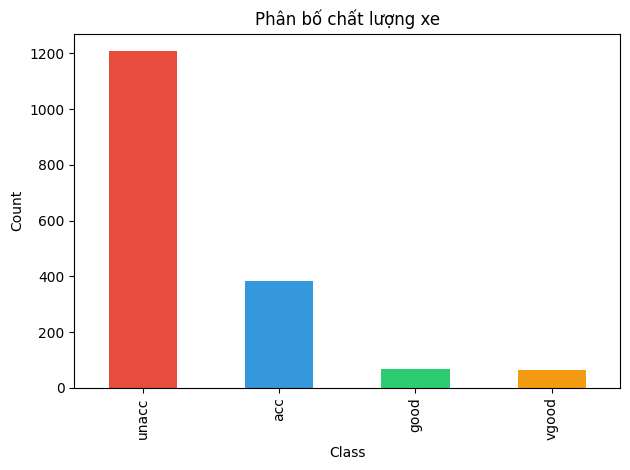

In [33]:
# 5.2 Khám phá dữ liệu
print('Phân bố nhãn:')
print(car['class'].value_counts())

car['class'].value_counts().plot(kind='bar', color=['#e74c3c','#3498db','#2ecc71','#f39c12'])
plt.title('Phân bố chất lượng xe')
plt.xlabel('Class'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

In [34]:
# 5.3 Tiền xử lý Car Dataset
car_clean = car.copy()

# Encode tất cả cột (đều là categorical)
le_car = LabelEncoder()
for col in car_clean.columns:
    car_clean[col] = le_car.fit_transform(car_clean[col])

# Lưu label encoder riêng cho cột class
le_class = LabelEncoder()
car['class_enc'] = le_class.fit_transform(car['class'])

X_car = car_clean.drop('class', axis=1).values
y_car = car_clean['class'].values

# One-hot encode cho y (vì 4 lớp)
y_car_ohe = tf.keras.utils.to_categorical(y_car, num_classes=4)

X_train_car, X_test_car, y_train_car, y_test_car = train_test_split(
    X_car, y_car_ohe, test_size=0.2, random_state=42
)

print('Train size:', X_train_car.shape)
print('Test  size:', X_test_car.shape)
print('Num classes:', y_car_ohe.shape[1])

Train size: (1382, 6)
Test  size: (346, 6)
Num classes: 4


In [35]:
# 5.4 Xây dựng mô hình ANN
car_model = Sequential([
    Dense(64, input_dim=X_train_car.shape[1],
          kernel_initializer='uniform', activation='relu'),
    Dropout(0.2),
    Dense(32, kernel_initializer='uniform', activation='relu'),
    Dense(4, activation='softmax')   # 4 classes
])

car_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
car_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,660 (10.39 KB)

 Trainable params: 2,660 (10.39 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# 5.5 Huấn luyện
car_fit = car_model.fit(
    X_train_car, y_train_car,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6702 - loss: 1.1635 - val_accuracy: 0.6259 - val_loss: 0.9747
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7144 - loss: 0.8138 - val_accuracy: 0.6259 - val_loss: 0.9345
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7144 - loss: 0.7677 - val_accuracy: 0.6259 - val_loss: 0.8835
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7144 - loss: 0.7326 - val_accuracy: 0.6331 - val_loss: 0.8490
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7224 - loss: 0.7017 - val_accuracy: 0.6403 - val_loss: 0.8330
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7257 - loss: 0.6843 - val_accuracy: 0.6259 - val_loss: 0.7990
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7233 - loss: 0.6661 - val_accuracy: 0.6331 - val_loss: 0.7784
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7208 - loss: 0.6455 - val_accuracy: 0.6403 - val_loss:

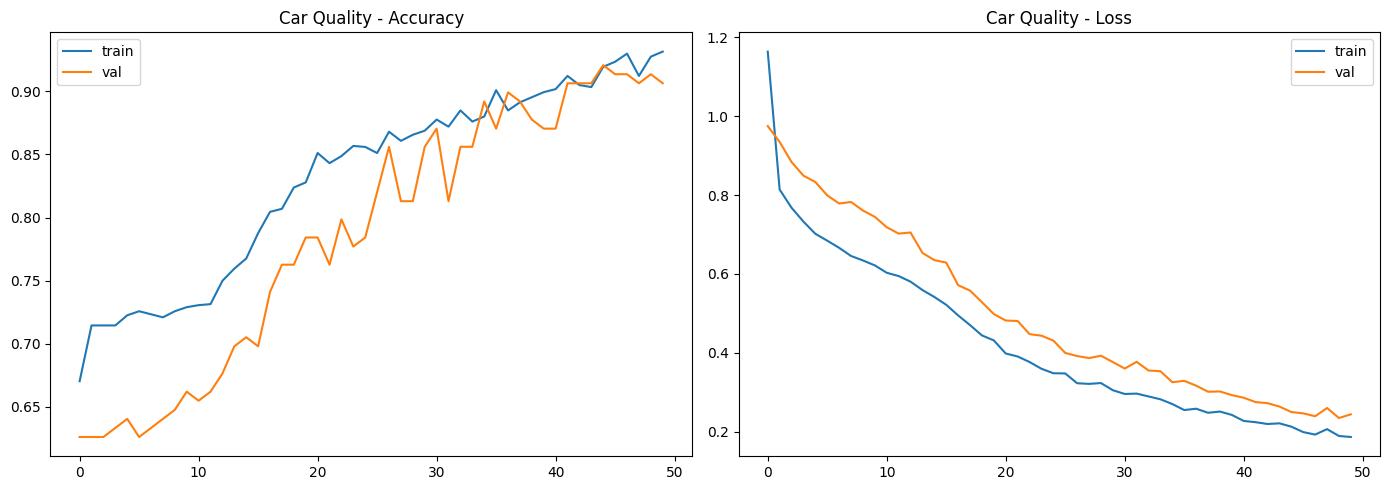

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Test Accuracy: 0.9335260115606936

Classification Report:
              precision    recall  f1-score   support

         acc       0.87      0.86      0.86        83
        good       0.86      0.55      0.67        11
       unacc       0.96      1.00      0.97       235
       vgood       1.00      0.71      0.83        17

    accuracy                           0.93       346
   macro avg       0.92      0.78      0.83       346
weighted avg       0.93      0.93      0.93       346



In [37]:
# 5.6 Đánh giá Car Model
class_names_car = ['acc', 'good', 'unacc', 'vgood']  # thứ tự sau LabelEncoder

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(car_fit.history['accuracy'], label='train')
ax1.plot(car_fit.history['val_accuracy'], label='val')
ax1.set_title('Car Quality - Accuracy'); ax1.legend()

ax2.plot(car_fit.history['loss'], label='train')
ax2.plot(car_fit.history['val_loss'], label='val')
ax2.set_title('Car Quality - Loss'); ax2.legend()
plt.tight_layout(); plt.show()

y_pred_car = np.argmax(car_model.predict(X_test_car), axis=1)
y_true_car = np.argmax(y_test_car, axis=1)
print('Test Accuracy:', accuracy_score(y_true_car, y_pred_car))
print('\nClassification Report:')
print(classification_report(y_true_car, y_pred_car, target_names=class_names_car))

In [38]:
# 5.7 Dự báo xe mới
# Ví dụ từ tập test
sample_car = X_test_car[0].reshape(1, -1)
prob_car = car_model.predict(sample_car)[0]
pred_car = class_names_car[np.argmax(prob_car)]
true_car = class_names_car[y_true_car[0]]

print('Xác suất theo từng lớp:')
for i, cls in enumerate(class_names_car):
    print(f'  {cls}: {prob_car[i]:.4f}')
print(f'\nDự báo: {pred_car} | Thực tế: {true_car}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Xác suất theo từng lớp:
  acc: 0.0022
  good: 0.0000
  unacc: 0.9978
  vgood: 0.0000

Dự báo: unacc | Thực tế: unacc
